# CW305-100t Adder Target — Test & Power Trace Capture

This notebook tests the simple 8-bit adder bitstream built from `cw305_top.v`.  
It walks through:
1. Connecting to the ChipWhisperer scope and CW305 target
2. Programming the FPGA and configuring the onboard PLL
3. Locking the scope ADC to the FPGA clock
4. Functional sanity checks via register read/write
5. Capturing power traces while the adder runs
6. Visualising and saving the traces

**Register map** (from `cw305_user_defines.v`):

| Define | Addr | Direction | Description |
|---|---|---|---|
| `REG_OPERAND_A` | 0 | R/W | First operand |
| `REG_OPERAND_B` | 1 | R/W | Second operand |
| `REG_RESULT_LO` | 2 | R   | Result bits [7:0] |
| `REG_RESULT_HI` | 3 | R   | Result bit  [8] (carry) |
| `REG_CRYPT_GO`  | 4 | R/W | Write 1 to trigger, auto-clears |
| `REG_USER_LED`  | 5 | —   | Reserved / LED |

> **Note:** `reg_address` in the FPGA is 14 bits wide  
> (`pADDR_WIDTH − pBYTECNT_SIZE = 21 − 7`).  
> The USB front-end strips the lower 7 byte-count bits before presenting the address.

## Cell 1 — Paths and imports

Set `BITFILE` and `DEFINES_FILE` to the files produced by Vivado implementation.

In [18]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
import time

# Paths — adjust if you move the project
BITFILE      = 'test1.runs/impl_1/cw305_top.bit'
DEFINES_FILE = 'test1.srcs/sources_1/new/cw305_user_defines.v'

print(f'Bitfile      : {BITFILE}')
print(f'Defines file : {DEFINES_FILE}')
print(f'ChipWhisperer: {cw.__version__}')

Bitfile      : test1.runs/impl_1/cw305_top.bit
Defines file : test1.srcs/sources_1/new/cw305_user_defines.v
ChipWhisperer: 6.0.0


## Cell 2 — Connect to the ChipWhisperer scope

`cw.scope()` auto-detects a connected CW-Lite or CW-Pro.  
`default_setup()` sets sensible gain/clock defaults that we will override below.

In [19]:
try:
    scope.dis()
except Exception:
    pass

scope = cw.scope()
scope.default_setup()
print(scope)

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 16965587                  to 77612114                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 29538459                 
scope.clock.adc_rate                     changed from 96000000.0                to 29538459.0               
scope.clock.clkgen_

## Cell 3 — Subclass CW305 for this design

ChipWhisperer's `CW305` class uses two class-level attributes to size its
internal register table:

* `registers` — must equal the number of `` `define REG_* `` lines in your defines file (6 here)
* `bytecount_size` — must equal `pBYTECNT_SIZE` in Verilog (7 here)

Subclassing is the cleanest way to set these without patching library code.

In [20]:
class MyCW305(cw.targets.CW305):
    """CW305 subclass configured for the 6-register adder design."""
    def __init__(self):
        super().__init__()
        self.registers      = 6   # number of `define REG_* in cw305_user_defines.v
        self.bytecount_size = 7   # pBYTECNT_SIZE in Verilog

print('MyCW305 defined — registers=6, bytecount_size=7')

MyCW305 defined — registers=6, bytecount_size=7


## Cell 4 — Program the FPGA

`cw.target()` loads the bitstream over USB and parses the defines file.  
After this cell completes, `target.REG_OPERAND_A` etc. are populated automatically
by `slurp_defines()` reading `cw305_user_defines.v`.

* `force=True` — re-programs even if the FPGA appears already configured
* `fpga_id='100t'` — selects the correct JTAG chain entry for the Artix-7 100T

In [21]:
try:
    target.dis()
except Exception:
    pass

target = cw.target(scope, MyCW305,
                   bsfile        = BITFILE,
                   force         = True,
                   fpga_id       = '100t',
                   platform      = 'cw305',
                   defines_files = [DEFINES_FILE])

print('FPGA programmed.')
print('Register addresses parsed from defines file:')
for name in ['REG_OPERAND_A', 'REG_OPERAND_B', 'REG_RESULT_LO',
             'REG_RESULT_HI', 'REG_CRYPT_GO', 'REG_USER_LED']:
    print(f'  target.{name} = {getattr(target, name, "NOT FOUND")}')

FPGA programmed.
Register addresses parsed from defines file:
  target.REG_OPERAND_A = 0
  target.REG_OPERAND_B = 1
  target.REG_RESULT_LO = 2
  target.REG_RESULT_HI = 3
  target.REG_CRYPT_GO = 4
  target.REG_USER_LED = 5


## Cell 5 — Configure the CW305 onboard PLL

The CW305 has a programmable PLL (CDCLVPx).  
Channel 1 is routed to FPGA pin N13 — that is `pll_clk1` in `cw305_top.v`,
which feeds the `BUFG → crypt_clk` path and is forwarded back out on `tio_clkout`
so the scope can lock its ADC to the same clock.

Start conservatively at **10 MHz** — the adder easily meets timing at this rate.

In [22]:
CLK_FREQ = 10e6   # Hz — change to e.g. 50e6 once you verify correct operation

target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(False, 0)   # channel 0 off
target.pll.pll_outenable_set(True,  1)   # channel 1 → pll_clk1 (N13)
target.pll.pll_outenable_set(False, 2)   # channel 2 off
target.pll.pll_outfreq_set(CLK_FREQ, 1)
time.sleep(0.1)

print(f'PLL channel 1 set to {CLK_FREQ/1e6:.1f} MHz')

PLL channel 1 set to 10.0 MHz


## Cell 6 — Lock the scope ADC to the FPGA clock

**Signal path:**  
`pll_clk1 (N13) → BUFG → crypt_clk → ODDR → tio_clkout (M16) → 20-pin → HS1 on CW-Lite`

`extclk_src` on the CW-Lite is hardwired to HS1 (read-only).  
HS2 is output-only (default: drives `clkgen` clock toward the target) — set it to
`'disabled'` so it does not fight the clock being driven by the FPGA onto HS1.

`extclk_x4` → ADC runs at 4× the incoming FPGA clock (40 MHz at 10 MHz input).
Falls back to `clkgen_x4` if HS1 has no clock (20-pin cable not connected yet).

> **Physical requirement:** the 20-pin ribbon cable must be seated on both boards
> before running this cell. It carries both the clock (tio_clkout → HS1) and the
> trigger signal (tio_trigger → tio4).

In [23]:
# HS2 is output-only; disable it so it does not drive onto HS1/the clock net.
scope.io.hs2 = 'disabled'

# Try to lock ADC to the FPGA clock arriving on HS1 via tio_clkout.
scope.clock.adc_src = 'extclk_x4'
scope.clock.reset_adc()
time.sleep(0.2)

if scope.clock.adc_locked and scope.clock.adc_freq > 1e6:
    print(f'ADC locked to EXTCLK (HS1).  Freq = {scope.clock.adc_freq / 1e6:.2f} MHz')
    print('Good — ADC is synchronised to the FPGA clock.')
else:
    print('WARNING: extclk (HS1) not detected — falling back to clkgen_x4.')
    print('Check: 20-pin ribbon seated on both boards; FPGA tio_clkout wired to HS1.')
    scope.clock.adc_src = 'clkgen_x4'
    scope.clock.clkgen_freq = CLK_FREQ
    scope.clock.reset_adc()
    time.sleep(0.1)
    assert scope.clock.adc_locked, 'Internal ADC clock (clkgen) failed to lock.'
    print(f'ADC locked to CLKGEN.  Freq = {scope.clock.adc_freq / 1e6:.2f} MHz')
    print('Captures will work but ADC is NOT synchronised to FPGA clock.')


ADC locked to EXTCLK (HS1).  Freq = 40.00 MHz
Good — ADC is synchronised to the FPGA clock.


## Cell 7 — Configure trigger and ADC capture window

**Valid `tio4` modes:** `high_z` · `serial_tx` · `gpio_low` · `gpio_high`  
(`gpio_in` does NOT exist — `high_z` IS the input/receive state for tio4.)

The default for tio4 is already `high_z`, so no direction change is needed.
`scope.trigger.triggers = 'tio4'` is sufficient — it routes the sampled pin
level to the trigger block.

**Trigger pulse width:** `tio_trigger` is held high for 64 `usb_clk` cycles
(~1.3 µs at 48 MHz USB clock) by a hardware stretcher in `cw305_top.v`.
This requires the bitfile rebuilt after the last Verilog change —
the old bitfile only produced a ~21 ns pulse that was unreliable.

In [24]:
# tio4 defaults to 'high_z' which IS the receive/input state — no change needed.
# 'gpio_in' is NOT a valid mode; valid modes: high_z, serial_tx, gpio_low, gpio_high.
scope.trigger.triggers = 'tio4'
scope.adc.samples      = 500
scope.adc.offset       = 0
scope.adc.basic_mode   = 'rising_edge'

print(f'tio4 direction : {scope.io.tio4}')   # should print high_z
print(f'Trigger source : {scope.trigger.triggers}')
print(f'ADC source     : {scope.clock.adc_src}')
print(f'Samples        : {scope.adc.samples}')


tio4 direction : high_z
Trigger source : tio4
ADC source     : extclk_x4
Samples        : 500


## Cell 8 — Register helpers

Thin wrappers around `target.fpga_write` / `target.fpga_read` for one-byte registers.

The CW305 USB front-end (`cw305_usb_reg_fe.v`) presents a byte-addressable interface:
the lower 7 bits of `usb_addr` are the *byte count* inside a register,
the upper 14 bits are the *register address* — that is what our defines encode.

In [25]:
REG_A         = target.REG_OPERAND_A
REG_B         = target.REG_OPERAND_B
REG_RESULT_LO = target.REG_RESULT_LO
REG_RESULT_HI = target.REG_RESULT_HI
REG_GO        = target.REG_CRYPT_GO

def write_reg(addr, value):
    target.fpga_write(addr, [int(value) & 0xFF])

def read_reg(addr):
    return target.fpga_read(addr, 1)[0]

print('Helpers ready.')
print(f'  REG_A={REG_A}, REG_B={REG_B}, REG_RESULT_LO={REG_RESULT_LO}, '
      f'REG_RESULT_HI={REG_RESULT_HI}, REG_GO={REG_GO}')

Helpers ready.
  REG_A=0, REG_B=1, REG_RESULT_LO=2, REG_RESULT_HI=3, REG_GO=4


## Cell 9 — Functional sanity checks

Before capturing power traces, verify the adder gives correct results.

Three test cases:
1. Simple sum that fits in 8 bits (100 + 200 = 300)
2. Sum with carry (200 + 200 = 400 → result_hi = 1)
3. Zero inputs (0 + 0 = 0)

In [26]:
def adder_test(a, b, label=''):
    write_reg(REG_A, a)
    write_reg(REG_B, b)
    write_reg(REG_GO, 1)
    time.sleep(0.005)              # 5 ms: crypt_clk (100 ns) + 2-FF sync + USB latency
    lo    = read_reg(REG_RESULT_LO)
    carry = read_reg(REG_RESULT_HI) & 0x01
    result = (carry << 8) | lo
    expected = a + b
    status = 'PASS' if result == expected else f'FAIL (expected {expected})'
    print(f'{label:20s}  {a:3d} + {b:3d} = {result:4d}  [{status}]')
    return result == expected

print(f'{"Test":<20}  {"A":>3}   {"B":>3}   {"Result":>5}  Status')
print('-' * 50)
all_ok  = adder_test(100, 200, 'normal sum')
all_ok &= adder_test(200, 200, 'carry out')
all_ok &= adder_test(  0,   0, 'zero')
all_ok &= adder_test(255, 255, 'max values')
all_ok &= adder_test( 17,  83, 'round numbers')

print()
print('All tests passed!' if all_ok else 'SOME TESTS FAILED — check register wiring.')

Test                    A     B   Result  Status
--------------------------------------------------
normal sum            100 + 200 =  300  [PASS]
carry out             200 + 200 =  400  [PASS]
zero                    0 +   0 =    0  [PASS]
max values            255 + 255 =  510  [PASS]
round numbers          17 +  83 =  100  [PASS]

All tests passed!


## Cell 10 — Capture power traces

Each iteration:
1. Write random operands A and B
2. Arm the scope (waits for trigger)
3. Write REG_GO=1 → FPGA asserts `tio_trigger` → scope fires
4. Read back the result to verify correctness alongside the trace

Traces where `scope.capture()` returns `True` timed out and are skipped.

In [27]:
N_TRACES  = 200
traces    = []
operands  = []   # list of (a, b, result) for later analysis
n_timeout = 0

rng = np.random.default_rng(seed=42)

for i in range(N_TRACES):
    a = int(rng.integers(0, 256))
    b = int(rng.integers(0, 256))

    write_reg(REG_A, a)
    write_reg(REG_B, b)

    scope.arm()
    write_reg(REG_GO, 1)       # pulse trigger; FPGA asserts tio_trigger

    if scope.capture():        # True = timeout
        n_timeout += 1
        continue

    trace = scope.get_last_trace()
    lo    = read_reg(REG_RESULT_LO)
    carry = read_reg(REG_RESULT_HI) & 0x01
    result = (carry << 8) | lo

    traces.append(trace)
    operands.append((a, b, result))

print(f'Captured {len(traces)}/{N_TRACES} traces  ({n_timeout} timeouts)')

# Verify all captured results
errors = [(a, b, r) for (a, b, r) in operands if r != a + b]
if errors:
    print(f'WARNING: {len(errors)} incorrect results — first few: {errors[:5]}')
else:
    print('All captured results are arithmetically correct.')

Captured 200/200 traces  (0 timeouts)
All captured results are arithmetically correct.


## Cell 11 — Plot: overlay of raw traces

Overlaying many traces lets you see the stable switching pattern of the adder.
The sharp spike near sample 0 is the carry-propagation glitch —
the main target of power-analysis attacks on arithmetic operations.

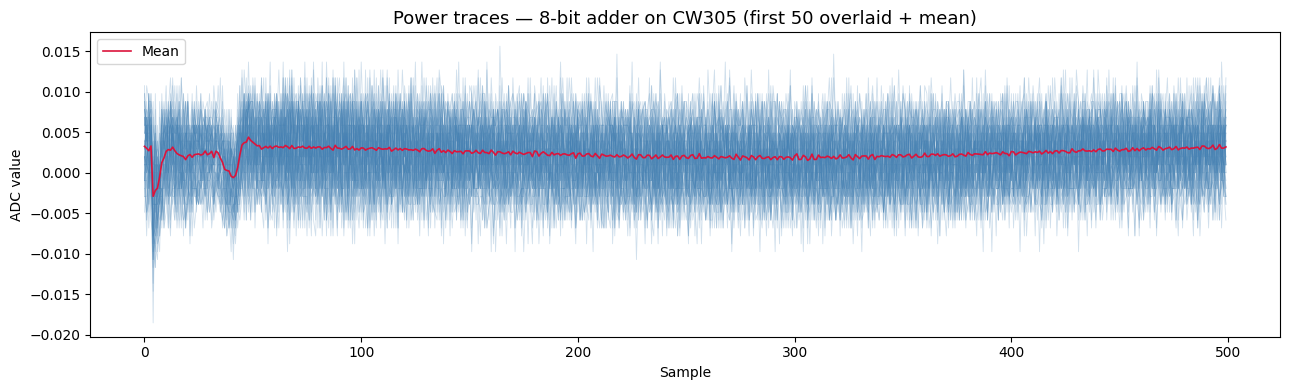

In [28]:
traces_np = np.array(traces)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(traces_np[:50].T, alpha=0.25, linewidth=0.6, color='steelblue')
ax.plot(traces_np.mean(axis=0), color='crimson', linewidth=1.2, label='Mean')
ax.set_title('Power traces — 8-bit adder on CW305 (first 50 overlaid + mean)', fontsize=13)
ax.set_xlabel('Sample')
ax.set_ylabel('ADC value')
ax.legend()
plt.tight_layout()
plt.show()

## Cell 12 — Plot: mean trace and per-sample variance

High variance at a sample position means the ADC value depends strongly on
the operand values — those are the most informative samples for power analysis.

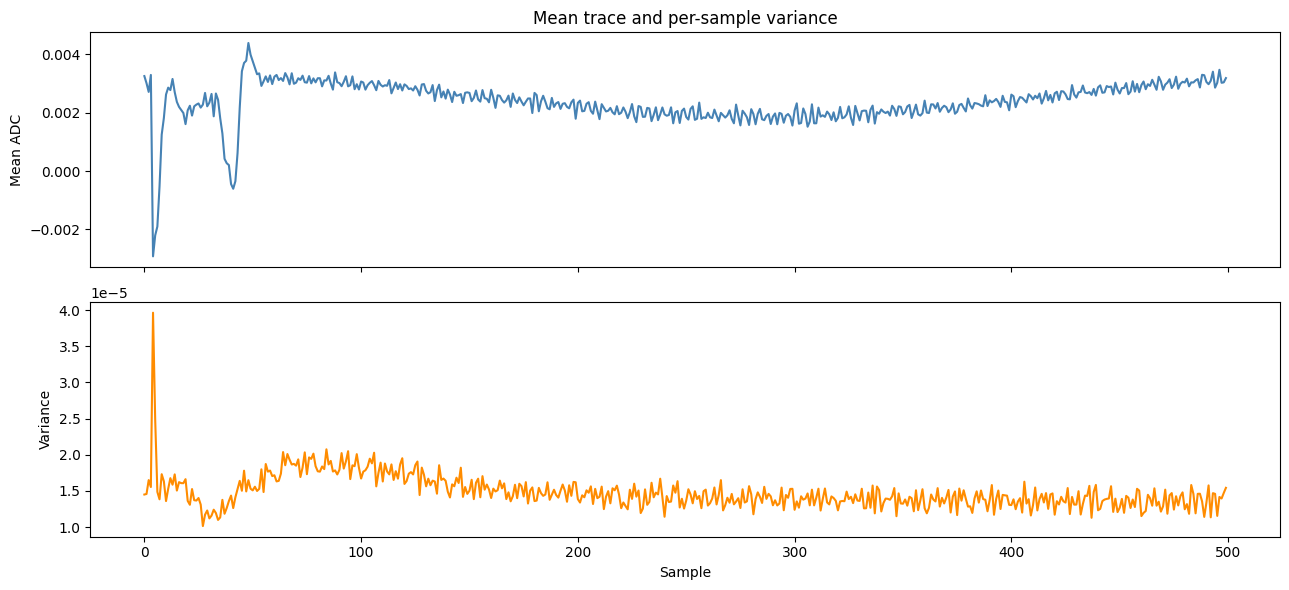

In [29]:
mean_trace = traces_np.mean(axis=0)
var_trace  = traces_np.var(axis=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax1.plot(mean_trace, color='steelblue')
ax1.set_ylabel('Mean ADC')
ax1.set_title('Mean trace and per-sample variance')

ax2.plot(var_trace, color='darkorange')
ax2.set_ylabel('Variance')
ax2.set_xlabel('Sample')

plt.tight_layout()
plt.show()

## Cell 13 — Basic correlation: power vs carry bit

Split traces by whether the addition produced a carry-out.  
A visible difference in the mean traces confirms the power consumption
leaks information about the carry — the classic 1-bit leakage model.

Traces with carry   : 101
Traces without carry: 99


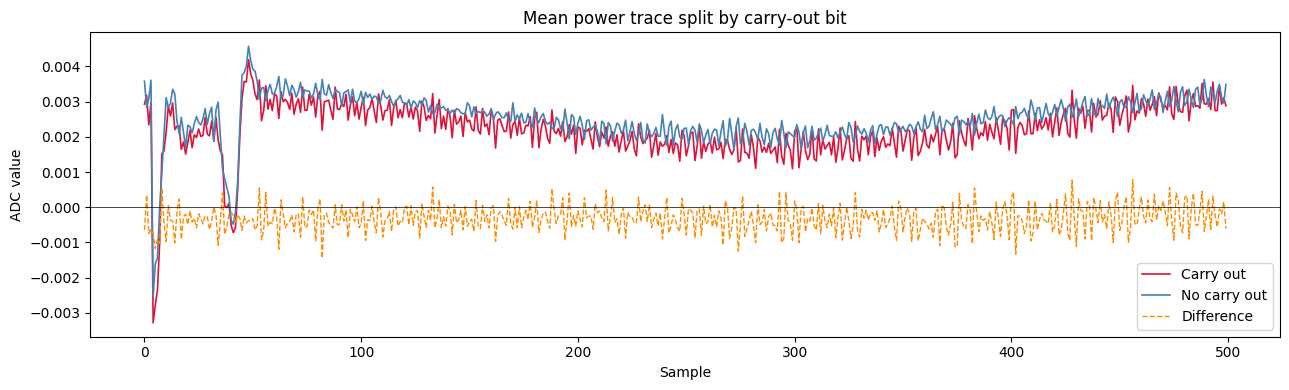

In [30]:
carry_idx    = [i for i, (a, b, r) in enumerate(operands) if r > 255]
no_carry_idx = [i for i, (a, b, r) in enumerate(operands) if r <= 255]

print(f'Traces with carry   : {len(carry_idx)}')
print(f'Traces without carry: {len(no_carry_idx)}')

if carry_idx and no_carry_idx:
    mean_carry    = traces_np[carry_idx].mean(axis=0)
    mean_no_carry = traces_np[no_carry_idx].mean(axis=0)

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(mean_carry,    label='Carry out',    color='crimson',   linewidth=1.2)
    ax.plot(mean_no_carry, label='No carry out', color='steelblue', linewidth=1.2)
    ax.plot(mean_carry - mean_no_carry, label='Difference',
            color='darkorange', linewidth=1.0, linestyle='--')
    ax.set_title('Mean power trace split by carry-out bit')
    ax.set_xlabel('Sample')
    ax.set_ylabel('ADC value')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough traces in one class — increase N_TRACES.')

## Cell 14 — Save traces to disk

Saves traces and operands as a compressed NumPy archive for offline analysis.

In [31]:
import os

save_path = 'traces_adder.npz'

operands_np = np.array(operands, dtype=np.uint16)   # columns: a, b, result
np.savez_compressed(save_path,
                    traces   = traces_np,
                    operands = operands_np)

size_kb = os.path.getsize(save_path) / 1024
print(f'Saved {len(traces_np)} traces  →  {save_path}  ({size_kb:.1f} KB)')
print(f'traces shape  : {traces_np.shape}')
print(f'operands shape: {operands_np.shape}  (columns: A, B, result)')

Saved 200 traces  →  traces_adder.npz  (85.4 KB)
traces shape  : (200, 500)
operands shape: (200, 3)  (columns: A, B, result)


## Cell 15 — Disconnect

Always disconnect cleanly to release the USB device.  
Re-run Cells 2–4 to reconnect.

In [ ]:
scope.dis()
target.dis()
print('Disconnected.')